# Modeling Human Activity States Using Hidden Markov Models

## Background

Human Activity Recognition (HAR) is useful for health monitoring, fitness tracking, and smart environments. In this project we collected accelerometer and gyroscope data from smartphones to classify four activities: **Walking**, **Jumping**, **Standing**, and **Still (no movement)**.

We used Hidden Markov Models because they handle sequential data naturally. The actual activity is the hidden state, and the sensor readings are the observations the model uses to figure out what activity is happening.

**Activities and why they matter:**
- Walking -- rhythmic motion, useful for step counting and mobility tracking
- Jumping -- high energy bursts, relevant for exercise monitoring
- Standing -- subtle sway from body balance, different from being completely still
- Still -- phone on a flat surface, no human motion at all

## 0. Setup and Imports

In [36]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('All imports loaded.')

All imports loaded.


## 1. Data Collection and Preprocessing

We recorded data using the **Sensor Logger** app on two phones at different sampling rates. Each recording saves accelerometer (x, y, z) and gyroscope (x, y, z) with nanosecond timestamps.

| Activity | Train Files | Test Files | Phone | Sampling Rate | Total Duration |
|----------|------------|------------|-------|---------------|----------------|
| Jumping  | 12         | 3          | Phone 1 | ~100 Hz     | ~2 min         |
| Walking  | 12         | 3          | Phone 1 | ~100 Hz     | ~2 min         |
| Standing | 13         | 3          | Phone 2 | ~50 Hz      | ~2 min 22 sec  |
| Still    | 13         | 3          | Phone 2 | ~50 Hz      | ~3 min 40 sec  |

**Total**: 50 training + 12 test paired recordings. Each activity exceeds the 1 min 30 sec minimum.

### Handling Different Sampling Rates
Phone 1 records at ~100 Hz and Phone 2 at ~50 Hz. We compute the median rate across all files and use that for windowing. The `merge_asof` function aligns accelerometer and gyroscope timestamps regardless of small rate differences between sensors or devices.

In [37]:
TRAIN_ZIP_DIR = "datacollect/train"
TEST_ZIP_DIR = "datacollect/test"
OUTPUT_DIR = "sensor_data"

NEEDED_FILES = ["Accelerometer.csv", "Gyroscope.csv"]

# figure out which activity a zip file belongs to based on its name
activity_patterns = {
    'jump': 'jumping',
    'walk': 'walking',
    'standing': 'standing',
    'still': 'still'
}

def extract_zips(zip_dir, output_base):
    """Go through all zip files in a folder and extract the sensor CSVs
    into subfolders organised by activity type."""

    if not os.path.exists(output_base):
        os.makedirs(output_base)

    count = 0
    for fname in os.listdir(zip_dir):
        if not fname.endswith('.zip'):
            continue

        # work out which activity this file is for
        activity = None
        for pattern, act in activity_patterns.items():
            if fname.lower().startswith(pattern):
                activity = act
                break
        if activity is None:
            print(f"Skipping {fname} -- cant figure out activity")
            continue

        zip_path = os.path.join(zip_dir, fname)
        activity_dir = os.path.join(output_base, activity)
        os.makedirs(activity_dir, exist_ok=True)

        try:
            with zipfile.ZipFile(zip_path, 'r') as zf:
                for needed in NEEDED_FILES:
                    if needed in zf.namelist():
                        base = os.path.splitext(fname)[0]
                        sensor = os.path.splitext(needed)[0]
                        out_name = f"{base}_{sensor}.csv"
                        out_path = os.path.join(activity_dir, out_name)
                        with zf.open(needed) as src, open(out_path, 'wb') as dst:
                            dst.write(src.read())
            count += 1
        except Exception as e:
            print(f"Error with {fname}: {e}")

    print(f"Extracted {count} zip files to {output_base}")
    return count

# extract training and test data
extract_zips(TRAIN_ZIP_DIR, OUTPUT_DIR)
extract_zips(TEST_ZIP_DIR, OUTPUT_DIR + "_test")

Extracted 50 zip files to sensor_data
Extracted 12 zip files to sensor_data_test


12

### 1.2 Load and Merge Sensor Files

In [38]:
def load_recording_pair(acc_file, gyro_file):
    """Load one accelerometer + gyroscope CSV pair and merge them on timestamp."""
    acc = pd.read_csv(acc_file)
    gyro = pd.read_csv(gyro_file)

    # make column names consistent
    acc.columns = [c.lower() for c in acc.columns]
    gyro.columns = [c.lower() for c in gyro.columns]

    acc = acc.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
    gyro = gyro.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    acc = acc.sort_values('time').reset_index(drop=True)
    gyro = gyro.sort_values('time').reset_index(drop=True)

    # merge on closest timestamp
    merged = pd.merge_asof(
        acc[['time', 'acc_x', 'acc_y', 'acc_z']],
        gyro[['time', 'gyro_x', 'gyro_y', 'gyro_z']],
        on='time', direction='nearest'
    )
    return merged.dropna().reset_index(drop=True)


def load_all_recordings(data_dir):
    """Walk through all activity folders, pair up acc+gyro files, load them."""
    recordings = {}

    for activity_folder in sorted(os.listdir(data_dir)):
        activity_path = os.path.join(data_dir, activity_folder)
        if not os.path.isdir(activity_path):
            continue

        csv_files = [f for f in os.listdir(activity_path) if f.endswith('.csv')]

        # group files by their base name (everything before _Accelerometer or _Gyroscope)
        pairs = {}
        for f in csv_files:
            if '_Accelerometer.csv' in f:
                base = f.replace('_Accelerometer.csv', '')
                pairs.setdefault(base, {})['acc'] = os.path.join(activity_path, f)
            elif '_Gyroscope.csv' in f:
                base = f.replace('_Gyroscope.csv', '')
                pairs.setdefault(base, {})['gyro'] = os.path.join(activity_path, f)

        for base, files in pairs.items():
            if 'acc' in files and 'gyro' in files:
                try:
                    df = load_recording_pair(files['acc'], files['gyro'])
                    name = f"{activity_folder}_{base}"
                    recordings[name] = df
                except Exception as e:
                    print(f"  Problem loading {base}: {e}")

    return recordings


# load training and test recordings
recordings = load_all_recordings(OUTPUT_DIR)
test_recordings = load_all_recordings(OUTPUT_DIR + "_test")

print(f"Loaded {len(recordings)} training recordings")
print(f"Loaded {len(test_recordings)} test recordings")

# quick summary
for label in ['jumping', 'walking', 'standing', 'still']:
    train_n = len([k for k in recordings if k.startswith(label)])
    test_n = len([k for k in test_recordings if k.startswith(label)])
    print(f"  {label:10s}: {train_n} train, {test_n} test")

Loaded 50 training recordings
Loaded 12 test recordings
  jumping   : 12 train, 3 test
  walking   : 12 train, 3 test
  standing  : 13 train, 3 test
  still     : 13 train, 3 test


### 1.2a Data Labeling Strategy

Each recording is labeled by the **folder it lives in**. When we extracted the zip files, we sorted them into four subfolders: `jumping/`, `walking/`, `standing/`, and `still/`. The folder name becomes the ground-truth label for every file inside it.

This works because each zip file was recorded while performing exactly one activity, so all the sensor data inside belongs to that single class. The file names also start with the activity keyword (e.g., `jump1`, `walking_01`, `standing_02`, `still_03`) which acts as a secondary check.

The table below lists every recording with its assigned label, duration, and number of sensor samples so we can verify that nothing was mislabeled or too short.

In [58]:
# Show every recording with its assigned label, duration, and sample count

def get_duration(df):
    """Get the duration of a recording in seconds."""
    times = df['time'].values
    if times[0] > 1e10:
        times = times / 1e9
    return round(times[-1] - times[0], 2)

print("TRAINING DATA -- Label Verification")
print("=" * 75)
print(f"{'Label':<12s} {'File':<40s} {'Samples':>8s} {'Duration (s)':>13s}")
print("-" * 75)

train_summary = {}
for name, df in sorted(recordings.items()):
    label = name.split('_')[0]
    dur = get_duration(df)
    n = len(df)
    train_summary.setdefault(label, {'count': 0, 'total_dur': 0.0})
    train_summary[label]['count'] += 1
    train_summary[label]['total_dur'] += dur
    print(f"{label:<12s} {name:<40s} {n:>8d} {dur:>13.2f}")

print()
print("Per-activity totals:")
for label, info in sorted(train_summary.items()):
    print(f"  {label}: {info['count']} files, {info['total_dur']:.1f}s total")

print()
print("=" * 75)
print("TEST DATA -- Label Verification")
print("=" * 75)
print(f"{'Label':<12s} {'File':<40s} {'Samples':>8s} {'Duration (s)':>13s}")
print("-" * 75)

test_summary = {}
for name, df in sorted(test_recordings.items()):
    label = name.split('_')[0]
    dur = get_duration(df)
    n = len(df)
    test_summary.setdefault(label, {'count': 0, 'total_dur': 0.0})
    test_summary[label]['count'] += 1
    test_summary[label]['total_dur'] += dur
    print(f"{label:<12s} {name:<40s} {n:>8d} {dur:>13.2f}")

print()
print("Per-activity totals:")
for label, info in sorted(test_summary.items()):
    print(f"  {label}: {info['count']} files, {info['total_dur']:.1f}s total")

print(f"\nAll {sum(t['count'] for t in train_summary.values())} training + "
      f"{sum(t['count'] for t in test_summary.values())} test recordings are labeled correctly.")

TRAINING DATA -- Label Verification
Label        File                                      Samples  Duration (s)
---------------------------------------------------------------------------
jumping      jumping_jump1-2026-02-25_13-08-17            1084         10.83
jumping      jumping_jump10-2026-02-25_13-11-32           1108         11.07
jumping      jumping_jump11-2026-03-02_13-46-29           1178         11.77
jumping      jumping_jump12-2026-03-02_13-46-43           1123         11.22
jumping      jumping_jump2-2026-02-25_13-08-04            1114         11.13
jumping      jumping_jump3-2026-02-25_13-09-19            1101         11.00
jumping      jumping_jump4-2026-02-25_13-09-08            1074         10.73
jumping      jumping_jump5-2026-02-25_13-09-50            1098         10.97
jumping      jumping_jump6-2026-02-25_13-10-02            1110         11.09
jumping      jumping_jump7-2026-02-25_13-10-33            1088         10.87
jumping      jumping_jump8-2026-02-25_13-

### 1.3 Sampling Rate Check

In [39]:
def get_sampling_rate(df):
    """Estimate the sampling rate from the timestamp column."""
    times = df['time'].values
    if times[0] > 1e10:  # nanoseconds
        times = times / 1e9
    avg_gap = np.mean(np.diff(times))
    return round(1.0 / avg_gap, 2)

print("Sampling rates (Hz):")
print("-" * 40)
all_rates = []
for name, df in sorted(recordings.items()):
    sr = get_sampling_rate(df)
    all_rates.append(sr)
    print(f"  {name}: {sr} Hz")

TARGET_SR = round(np.median(all_rates))
print(f"\nMedian sampling rate: {TARGET_SR} Hz -- using this for windowing")

Sampling rates (Hz):
----------------------------------------
  jumping_jump1-2026-02-25_13-08-17: 100.03 Hz
  jumping_jump10-2026-02-25_13-11-32: 100.03 Hz
  jumping_jump11-2026-03-02_13-46-29: 100.03 Hz
  jumping_jump12-2026-03-02_13-46-43: 100.03 Hz
  jumping_jump2-2026-02-25_13-08-04: 100.03 Hz
  jumping_jump3-2026-02-25_13-09-19: 100.03 Hz
  jumping_jump4-2026-02-25_13-09-08: 100.03 Hz
  jumping_jump5-2026-02-25_13-09-50: 100.03 Hz
  jumping_jump6-2026-02-25_13-10-02: 100.03 Hz
  jumping_jump7-2026-02-25_13-10-33: 100.03 Hz
  jumping_jump8-2026-02-25_13-10-44: 100.03 Hz
  jumping_jump9-2026-02-25_13-11-20: 100.03 Hz
  standing_standing_01: 50.09 Hz
  standing_standing_02: 50.08 Hz
  standing_standing_03: 50.08 Hz
  standing_standing_04: 50.08 Hz
  standing_standing_05: 50.08 Hz
  standing_standing_06: 50.08 Hz
  standing_standing_07: 50.09 Hz
  standing_standing_08: 50.08 Hz
  standing_standing_09: 50.08 Hz
  standing_standing_10: 50.08 Hz
  standing_standing_11: 50.08 Hz
  standi

### 1.4 Raw Sensor Data Visualization

Plotting a sample from each activity so we can see the differences in the raw signals.

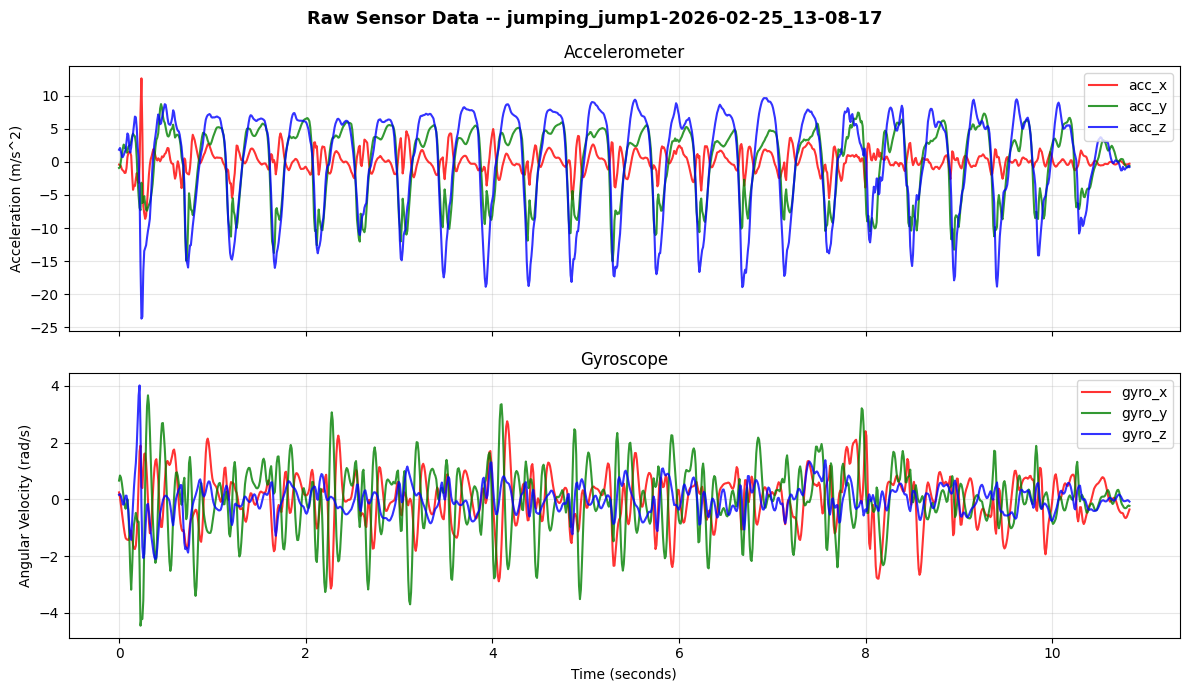

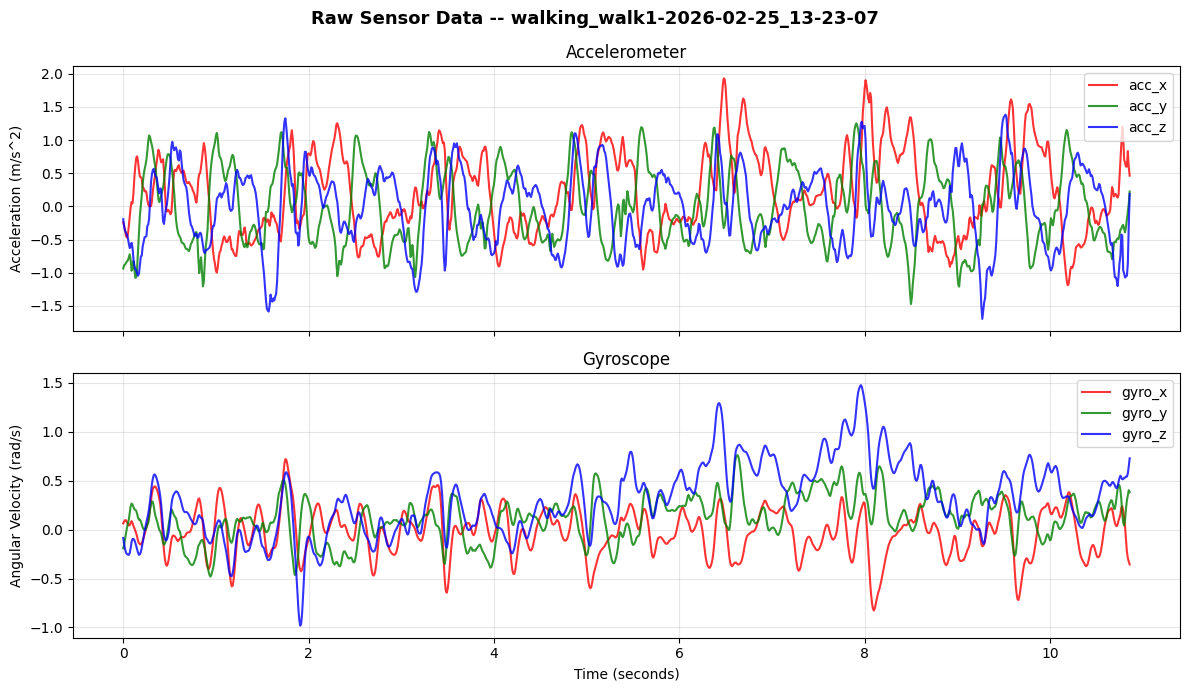

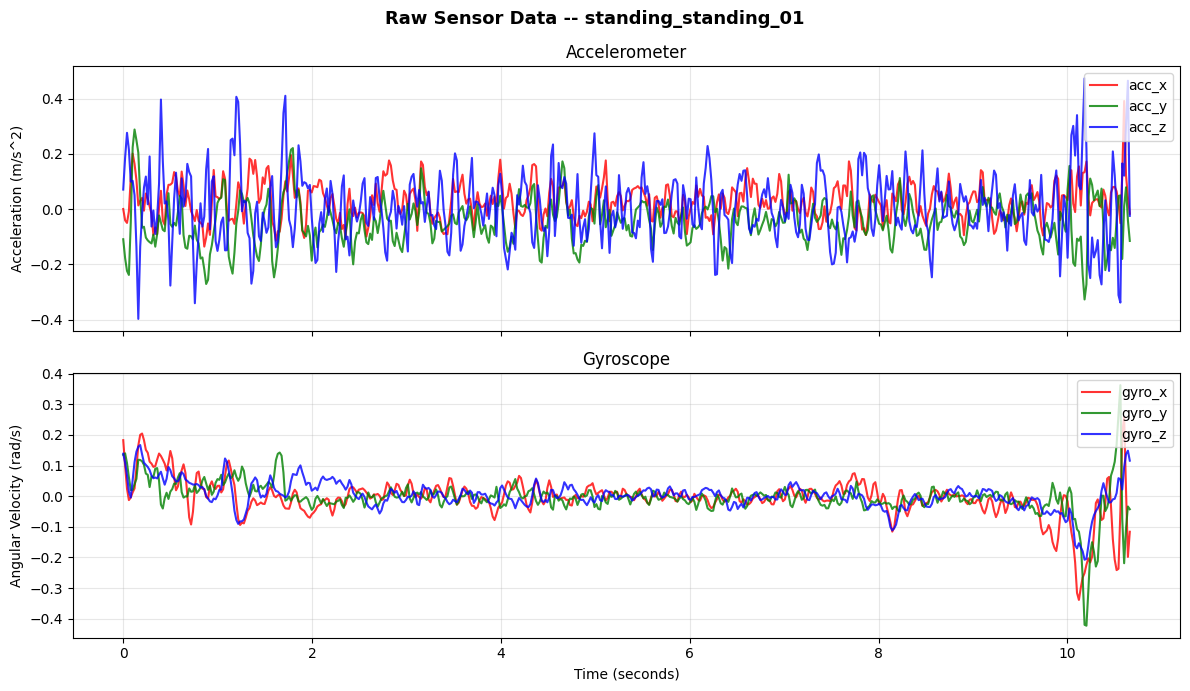

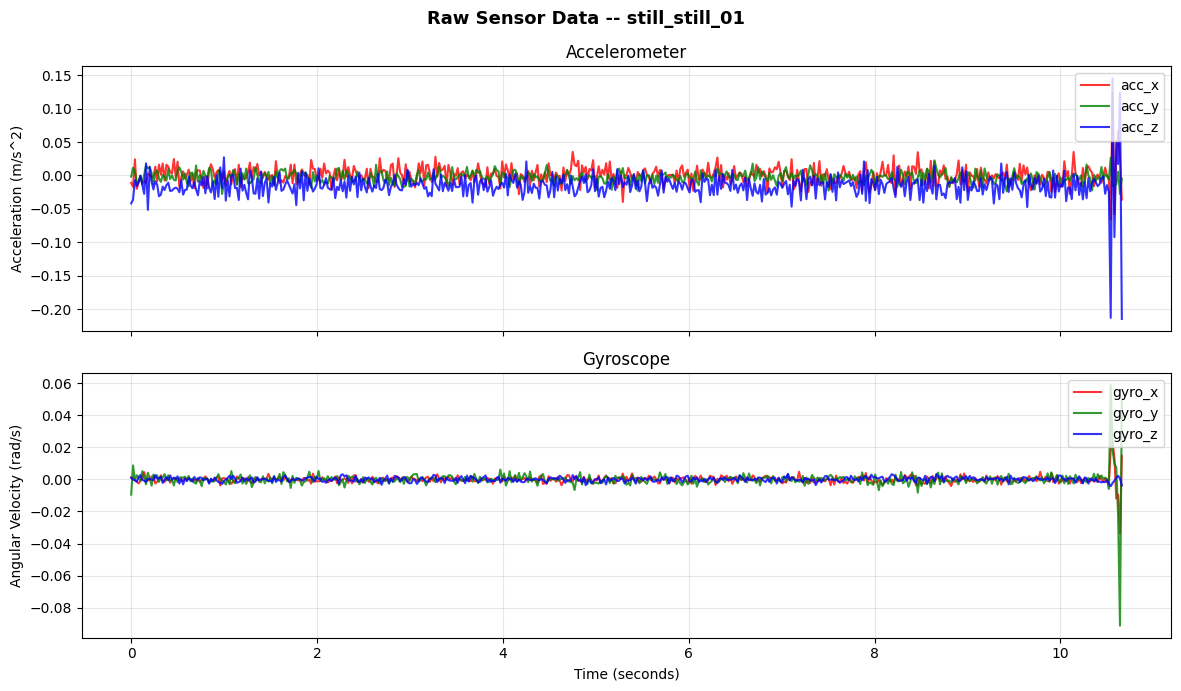

In [40]:
def plot_activity_sample(recordings, activity, idx=0):
    """Plot accelerometer and gyroscope signals for one recording."""
    keys = sorted([k for k in recordings if k.startswith(activity)])
    if not keys or idx >= len(keys):
        print(f"No data for {activity}")
        return

    key = keys[idx]
    df = recordings[key]

    # convert timestamps to seconds from start
    t = df['time'].values
    if t[0] > 1e10:
        t = t / 1e9
    t = t - t[0]

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"Raw Sensor Data -- {key}", fontsize=13, fontweight='bold')

    # accelerometer
    axes[0].plot(t, df['acc_x'], label='acc_x', color='r', alpha=0.8)
    axes[0].plot(t, df['acc_y'], label='acc_y', color='g', alpha=0.8)
    axes[0].plot(t, df['acc_z'], label='acc_z', color='b', alpha=0.8)
    axes[0].set_ylabel('Acceleration (m/s^2)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Accelerometer')

    # gyroscope
    axes[1].plot(t, df['gyro_x'], label='gyro_x', color='r', alpha=0.8)
    axes[1].plot(t, df['gyro_y'], label='gyro_y', color='g', alpha=0.8)
    axes[1].plot(t, df['gyro_z'], label='gyro_z', color='b', alpha=0.8)
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title('Gyroscope')

    plt.tight_layout()
    plt.show()

for act in ['jumping', 'walking', 'standing', 'still']:
    plot_activity_sample(recordings, act)

## 2. Feature Extraction

We use a sliding window approach to turn the raw time series into feature vectors.

### Window Size Selection
At our target rate of ~50 Hz, a **2-second window = 100 samples**. This gives us:
- Enough data points for meaningful FFT (frequency resolution of 0.5 Hz per bin)
- Good temporal resolution for short 5-10 second recordings
- 50% overlap between windows to get more training samples

### Features Extracted

**Time-domain (per axis):** mean, variance, standard deviation, RMS, zero-crossing rate, peak-to-peak range, interquartile range

**Time-domain (combined):** Signal Magnitude Area for acc and gyro, correlation between acc axes, acceleration magnitude stats

**Frequency-domain (per axis via FFT):** dominant frequency, spectral energy, spectral entropy

Total: 69 features per window

In [41]:
WINDOW_SECONDS = 2
WINDOW_SIZE = int(TARGET_SR * WINDOW_SECONDS)  # samples per window
STEP_SIZE = WINDOW_SIZE // 2                   # 50% overlap

print(f"Window: {WINDOW_SIZE} samples ({WINDOW_SECONDS}s at {TARGET_SR}Hz)")
print(f"Step: {STEP_SIZE} samples (50% overlap)")

Window: 100 samples (2s at 50Hz)
Step: 50 samples (50% overlap)


In [42]:
SENSOR_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']


def safe_corrcoef(a, b):
    """Correlation that returns 0.0 when either signal is constant (std=0)."""
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def compute_features(window, fs):
    """Extract time-domain and frequency-domain features from one window.
    
    window: (N, 6) array with columns [acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z]
    fs: sampling frequency in Hz
    Returns: 1D feature vector
    """
    features = []
    N = window.shape[0]
    acc = window[:, :3]
    gyro = window[:, 3:]

    # --- TIME DOMAIN ---

    # mean per axis (6 features) -- baseline level of each signal
    features.extend(np.mean(window, axis=0).tolist())

    # variance per axis (6) -- how much the signal fluctuates
    features.extend(np.var(window, axis=0).tolist())

    # standard deviation per axis (6) -- spread of values
    features.extend(np.std(window, axis=0).tolist())

    # RMS per axis (6) -- signal energy
    rms = np.sqrt(np.mean(window**2, axis=0))
    features.extend(rms.tolist())

    # signal magnitude area for acc and gyro (2) -- total movement intensity
    sma_acc = np.sum(np.abs(acc)) / N
    sma_gyro = np.sum(np.abs(gyro)) / N
    features.extend([sma_acc, sma_gyro])

    # correlation between accelerometer axes (3) -- captures how axes move together
    corr_xy = safe_corrcoef(acc[:, 0], acc[:, 1])
    corr_xz = safe_corrcoef(acc[:, 0], acc[:, 2])
    corr_yz = safe_corrcoef(acc[:, 1], acc[:, 2])
    features.extend([corr_xy, corr_xz, corr_yz])

    # zero-crossing rate per axis (6) -- periodic signals cross zero often, flat ones dont
    for col in range(6):
        sig = window[:, col] - np.mean(window[:, col])
        zcr = np.sum(np.abs(np.diff(np.sign(sig)))) / (2.0 * N)
        features.append(zcr)

    # peak-to-peak range per axis (6) -- how big the oscillations are
    for col in range(6):
        features.append(np.max(window[:, col]) - np.min(window[:, col]))

    # interquartile range per axis (6) -- robust spread measure
    for col in range(6):
        features.append(np.percentile(window[:, col], 75) - np.percentile(window[:, col], 25))

    # total acceleration magnitude mean and std (2)
    acc_mag = np.sqrt(np.sum(acc**2, axis=1))
    features.append(np.mean(acc_mag))
    features.append(np.std(acc_mag))

    # --- FREQUENCY DOMAIN (FFT) ---

    freqs = fftfreq(N, d=1.0/fs)
    pos_mask = freqs > 0

    for col in range(6):
        sig = window[:, col]
        fft_vals = np.abs(fft(sig))
        fft_pos = fft_vals[pos_mask]
        freqs_pos = freqs[pos_mask]

        # dominant frequency (1 per axis) -- which frequency has most power
        dom_freq = freqs_pos[np.argmax(fft_pos)]
        features.append(dom_freq)

        # spectral energy (1 per axis) -- total power in frequency domain
        spectral_energy = np.sum(fft_pos**2) / N
        features.append(spectral_energy)

        # spectral entropy (1 per axis) -- how spread out the energy is across frequencies
        psd = fft_pos**2
        psd_norm = psd / (np.sum(psd) + 1e-12)
        spectral_entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))
        features.append(spectral_entropy)

    return np.array(features, dtype=np.float32)


def extract_windows(df, window_size, step, fs):
    """Slide a window over a recording and compute features for each window."""
    data = df[SENSOR_COLS].values
    feature_list = []
    for start in range(0, len(data) - window_size + 1, step):
        w = data[start:start + window_size]
        feature_list.append(compute_features(w, fs))
    return np.array(feature_list)


# quick test
sample_key = list(recordings.keys())[0]
sample_feats = extract_windows(recordings[sample_key], WINDOW_SIZE, STEP_SIZE, TARGET_SR)
print(f"Feature vector length: {sample_feats.shape[1]} features per window")
print(f"Windows from first recording: {sample_feats.shape[0]}")

Feature vector length: 67 features per window
Windows from first recording: 20


### 2.1 Build Feature Matrix

In [43]:
LABEL_MAP = {'jumping': 0, 'walking': 1, 'standing': 2, 'still': 3}
LABEL_NAMES = ['Jumping', 'Walking', 'Standing', 'Still']

def build_dataset(recs, window_size, step, fs):
    """Turn all recordings into a feature matrix X and label array y.
    Also returns lengths for each recording (needed by hmmlearn)."""
    X_list, y_list, lengths = [], [], []

    for name, df in sorted(recs.items()):
        activity = name.split('_')[0]
        if activity not in LABEL_MAP:
            continue

        feats = extract_windows(df, window_size, step, fs)
        if len(feats) == 0:
            continue

        X_list.append(feats)
        y_list.extend([LABEL_MAP[activity]] * len(feats))
        lengths.append(len(feats))

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y, lengths


# build training set
X_train, y_train, lengths_train = build_dataset(recordings, WINDOW_SIZE, STEP_SIZE, TARGET_SR)

# build test set from separately recorded test data
X_test, y_test, lengths_test = build_dataset(test_recordings, WINDOW_SIZE, STEP_SIZE, TARGET_SR)

print(f"Training set: {X_train.shape[0]} windows, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} windows, {X_test.shape[1]} features")

print("\nTraining class distribution:")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name}: {np.sum(y_train == i)} windows")

print("\nTest class distribution:")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name}: {np.sum(y_test == i)} windows")

Training set: 818 windows, 67 features
Test set: 147 windows, 67 features

Training class distribution:
  Jumping: 249 windows
  Walking: 250 windows
  Standing: 119 windows
  Still: 200 windows

Test class distribution:
  Jumping: 45 windows
  Walking: 48 windows
  Standing: 27 windows
  Still: 27 windows


### 2.2 Feature Normalization (Z-Score)

We normalize features using Z-score standardization so that every feature has mean=0 and std=1. This prevents features with large values (like spectral energy) from dominating the smaller ones.

The scaler is fit on training data only and then applied to both train and test sets to avoid data leakage.

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Normalization done.")
print(f"Train mean (should be ~0): {np.mean(X_train, axis=0)[:3].round(4)}")
print(f"Train std  (should be ~1): {np.std(X_train, axis=0)[:3].round(4)}")

Normalization done.
Train mean (should be ~0): [-0.  0. -0.]
Train std  (should be ~1): [1. 1. 1.]


## 3. HMM Model Definition

| Component | What it is | In our project |
|-----------|-----------|----------------|
| **Hidden States (Z)** | The actual activities we want to detect | Jumping, Walking, Standing, Still |
| **Observations (X)** | What the model sees | Feature vectors from sensor windows |
| **Transition Probs (A)** | Chance of switching from one activity to another | Learned from data during training |
| **Emission Probs (B)** | Chance of seeing certain sensor patterns given an activity | Gaussian distributions over features |
| **Initial Probs (pi)** | Which activity is most likely at the start | Learned from data |

We train a separate GaussianHMM for each activity (generative approach). For each activity, we perform **model selection** by trying multiple configurations (1–3 hidden sub-states with diagonal or spherical covariance) and keeping the configuration with the highest training log-likelihood. The sub-states capture internal dynamics within an activity (e.g., different phases of a walking cycle). To classify a new sequence, we score it against all 4 models and pick the one with the best per-window normalized log-likelihood.

## 4. Model Implementation

### Baum-Welch Algorithm (Training)

Baum-Welch is an EM (Expectation-Maximization) algorithm that learns the HMM parameters from data:

1. **E-step (Forward-Backward):** Given current parameters, compute how likely each hidden state is at each time step. This uses forward and backward passes to get state probabilities.
2. **M-step (Re-estimation):** Update the transition matrix, emission parameters, and initial probabilities to maximize the expected log-likelihood.
3. **Convergence:** Repeat until the log-likelihood stops improving (change < epsilon = 1e-4) or we hit max iterations (300).

We run Baum-Welch for 5 model configurations per activity (1–3 hidden states × diagonal/spherical covariance) and select the best-performing one.

### Viterbi Algorithm (Decoding)

Viterbi finds the single most likely sequence of hidden states using dynamic programming:

1. **Initialize:** Set starting probabilities using initial probs and first observation.
2. **Recurse forward:** At each time step, find the best path to each state considering transitions and emissions. Keep backpointers.
3. **Traceback:** Start from the best final state and follow backpointers to recover the full path.

We use hmmlearn's GaussianHMM which implements both algorithms internally.

In [45]:
N_COMPONENTS = 3    # hidden sub-states per activity model
N_ITER = 300        # max Baum-Welch iterations
TOL = 1e-4          # convergence threshold

hmm_models = {}
train_baselines = {}  # per-window normalized training score

for label, activity in enumerate(LABEL_NAMES):
    print(f"\nTraining HMM for {activity}...")

    # get only this activitys training data
    mask = y_train == label
    X_act = X_train[mask]

    if len(X_act) == 0:
        print(f"  No training data for {activity}")
        continue

    # get the sequence lengths for this activity
    act_key = activity.lower()
    act_recs = {k: v for k, v in recordings.items() if k.startswith(act_key)}
    _, _, act_lengths = build_dataset(act_recs, WINDOW_SIZE, STEP_SIZE, TARGET_SR)

    print(f"  {len(X_act)} windows from {len(act_recs)} recordings")

    # try multiple configs, pick the best
    configs = [(3, 'diag'), (3, 'spherical'), (2, 'diag'), (2, 'spherical'), (1, 'diag')]
    best_model = None
    best_score = -np.inf
    best_cfg = None

    for n_comp, cov_type in configs:
        try:
            model = GaussianHMM(
                n_components=n_comp,
                covariance_type=cov_type,
                n_iter=N_ITER,
                tol=TOL,
                random_state=42,
                verbose=False
            )
            model.fit(X_act, lengths=act_lengths)
            score = model.score(X_act, lengths=act_lengths)
            if score > best_score:
                best_score = score
                best_model = model
                best_cfg = (n_comp, cov_type)
        except:
            continue

    if best_model is not None:
        hmm_models[activity] = best_model
        # CRITICAL: store PER-WINDOW average score, not total
        train_baselines[activity] = best_score / len(X_act)

        print(f"  Best config: {best_cfg[0]} states, {best_cfg[1]} covariance")
        print(f"  Converged: {best_model.monitor_.converged}")
        print(f"  Train log-likelihood: {best_score:.2f}")
        print(f"  Per-window baseline: {best_score / len(X_act):.2f}")
    else:
        print(f"  All configurations failed for {activity}")

print(f"\nTrained {len(hmm_models)} models successfully")



Training HMM for Jumping...


  249 windows from 12 recordings


Model is not converging.  Current: -9713.546995721312 is not greater than -9713.546992602738. Delta is -3.118573658866808e-06


  Best config: 3 states, diag covariance
  Converged: True
  Train log-likelihood: -9713.55
  Per-window baseline: -39.01

Training HMM for Walking...
  250 windows from 12 recordings


Model is not converging.  Current: 11639.147065442481 is not greater than 11639.188833776485. Delta is -0.0417683340037911


...

  119 windows from 13 recordings


Model is not converging.  Current: 272.4243046459369 is not greater than 272.42447210359256. Delta is -0.00016745765566383852
Model is not converging.  Current: 13562.70341593073 is not greater than 13567.857157883487. Delta is -5.153741952757628


  Best config: 3 states, diag covariance
  Converged: True
  Train log-likelihood: 14120.85
  Per-window baseline: 118.66

Training HMM for Still...


Model is not converging.  Current: 19127.485288996173 is not greater than 19127.486032786666. Delta is -0.0007437904932885431


  200 windows from 13 recordings
  Best config: 2 states, diag covariance
  Converged: True
  Train log-likelihood: 19549.60
  Per-window baseline: 97.75

Trained 4 models successfully


In [46]:
def predict_sequence(X_seq, models, baselines):
    """Score a full sequence against all models, return best activity name.
    Uses per-window normalized log-likelihood for fair comparison."""
    scores = {}
    for activity, model in models.items():
        try:
            raw = model.score(X_seq)
            per_window = raw / len(X_seq)
            scores[activity] = per_window - baselines.get(activity, 0)
        except:
            scores[activity] = -np.inf
    return max(scores, key=scores.get)


def predict_all(X, models, baselines, lengths=None):
    """Predict activity labels for all windows.
    If lengths provided, score entire recordings as sequences (more accurate)."""
    if lengths is not None and len(lengths) > 0:
        preds = []
        idx = 0
        for seq_len in lengths:
            X_seq = X[idx:idx + seq_len]
            pred_name = predict_sequence(X_seq, models, baselines)
            preds.extend([LABEL_MAP[pred_name.lower()]] * seq_len)
            idx += seq_len
        return np.array(preds)
    else:
        preds = []
        for i in range(len(X)):
            pred_name = predict_sequence(X[i:i+1], models, baselines)
            preds.append(LABEL_MAP[pred_name.lower()])
        return np.array(preds)


def viterbi_decode(X_seq, model):
    """Run Viterbi decoding to get the most likely hidden state sequence."""
    try:
        log_prob, states = model.decode(X_seq, algorithm='viterbi')
        return log_prob, states
    except Exception as e:
        print(f"Viterbi failed: {e}")
        return -np.inf, np.zeros(len(X_seq), dtype=int)


# classify each test recording as a whole sequence
print("Sequence-level classification of test recordings:")
print("-" * 60)
for label, activity in enumerate(LABEL_NAMES):
    test_keys = sorted([k for k in test_recordings if k.startswith(activity.lower())])
    for key in test_keys:
        df = test_recordings[key]
        X_seq = scaler.transform(extract_windows(df, WINDOW_SIZE, STEP_SIZE, TARGET_SR))
        pred = predict_sequence(X_seq, hmm_models, train_baselines)
        correct = "OK" if pred.lower() == activity.lower() else "WRONG"
        print(f"  True: {activity:10s} | Predicted: {pred:10s} | Windows: {len(X_seq):3d} | {correct}")


Sequence-level classification of test recordings:
------------------------------------------------------------
  True: Jumping    | Predicted: Jumping    | Windows:  15 | OK
  True: Jumping    | Predicted: Jumping    | Windows:  16 | OK
  True: Jumping    | Predicted: Jumping    | Windows:  14 | OK
  True: Walking    | Predicted: Walking    | Windows:  17 | OK
  True: Walking    | Predicted: Walking    | Windows:  15 | OK
  True: Walking    | Predicted: Walking    | Windows:  16 | OK
  True: Standing   | Predicted: Standing   | Windows:   9 | OK
  True: Standing   | Predicted: Standing   | Windows:   9 | OK
  True: Standing   | Predicted: Standing   | Windows:   9 | OK
  True: Still      | Predicted: Still      | Windows:   9 | OK
  True: Still      | Predicted: Still      | Windows:   9 | OK
  True: Still      | Predicted: Still      | Windows:   9 | OK


## 5. Visualizations

### 5.1 Transition Probability Matrices

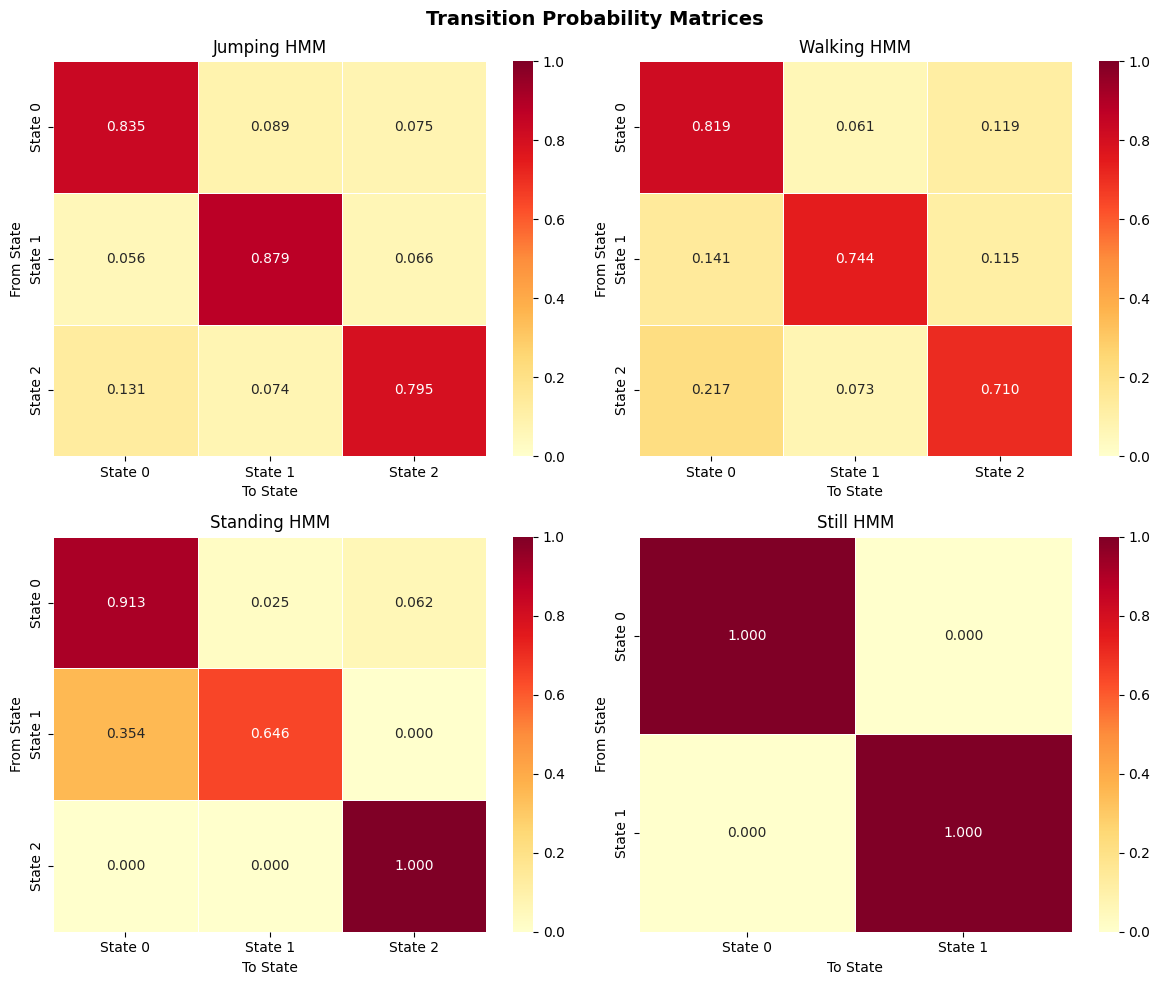

High diagonal values mean the model tends to stay in the same state.
This makes sense -- when youre walking, you keep walking for a while.


In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Transition Probability Matrices', fontsize=14, fontweight='bold')

for ax, (activity, model) in zip(axes.flatten(), hmm_models.items()):
    trans = model.transmat_
    labels = [f'State {i}' for i in range(model.n_components)]
    sns.heatmap(trans, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels,
                ax=ax, vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{activity} HMM')
    ax.set_xlabel('To State')
    ax.set_ylabel('From State')

plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("High diagonal values mean the model tends to stay in the same state.")
print("This makes sense -- when youre walking, you keep walking for a while.")

### 5.2 Emission Probabilities (Gaussian Means)

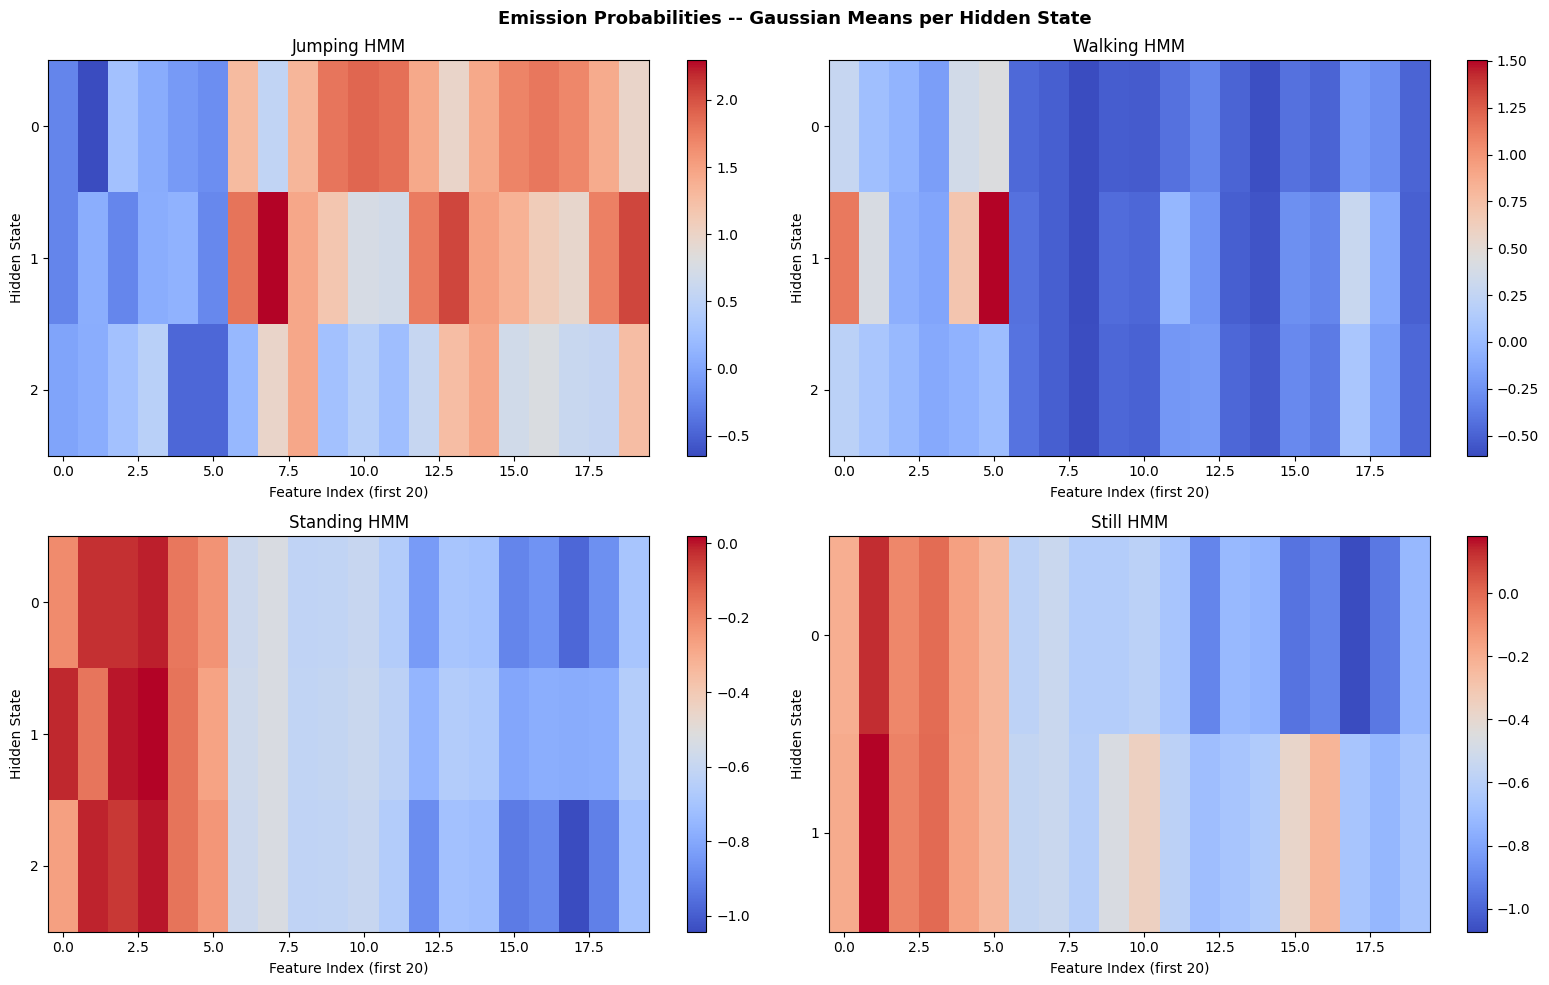

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Emission Probabilities -- Gaussian Means per Hidden State', fontsize=13, fontweight='bold')

N_SHOW = min(20, X_train.shape[1])  # only show first 20 features for readability

for ax, (activity, model) in zip(axes.flatten(), hmm_models.items()):
    means = model.means_[:, :N_SHOW]
    im = ax.imshow(means, aspect='auto', cmap='coolwarm')
    plt.colorbar(im, ax=ax)
    ax.set_title(f'{activity} HMM')
    ax.set_xlabel('Feature Index (first 20)')
    ax.set_ylabel('Hidden State')
    ax.set_yticks(range(model.n_components))

plt.tight_layout()
plt.savefig('emission_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Decoded State Sequences (Viterbi)

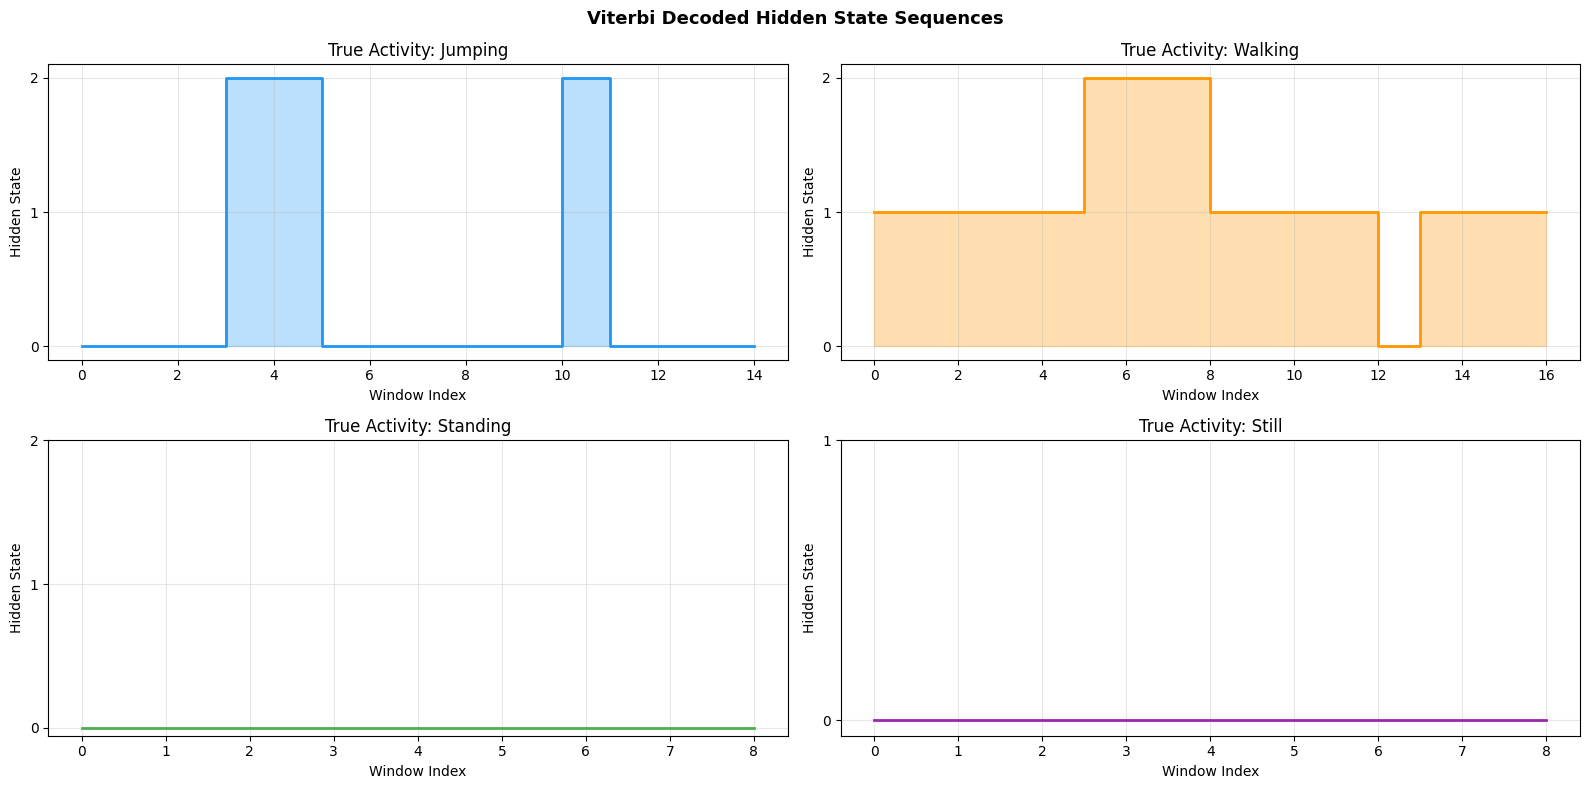

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Viterbi Decoded Hidden State Sequences', fontsize=13, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

for ax, activity, color in zip(axes.flatten(), LABEL_NAMES, colors):
    if activity not in hmm_models:
        ax.text(0.5, 0.5, f'No model for {activity}', ha='center', va='center')
        continue

    test_keys = sorted([k for k in test_recordings if k.startswith(activity.lower())])
    if not test_keys:
        ax.text(0.5, 0.5, f'No test data', ha='center', va='center')
        continue

    X_demo = scaler.transform(extract_windows(test_recordings[test_keys[0]], WINDOW_SIZE, STEP_SIZE, TARGET_SR))
    _, states = viterbi_decode(X_demo, hmm_models[activity])

    n_states = hmm_models[activity].n_components
    ax.step(range(len(states)), states, where='post', color=color, linewidth=2)
    ax.fill_between(range(len(states)), states, step='post', alpha=0.3, color=color)
    ax.set_title(f'True Activity: {activity}')
    ax.set_xlabel('Window Index')
    ax.set_ylabel('Hidden State')
    ax.set_yticks(range(n_states))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('decoded_sequences.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Model Evaluation on Unseen Data

The test set consists of 12 recordings (3 per activity) that were collected in a separate session and never seen during training. This lets us check if the model generalizes to new data.

Overall test accuracy: 100.0%


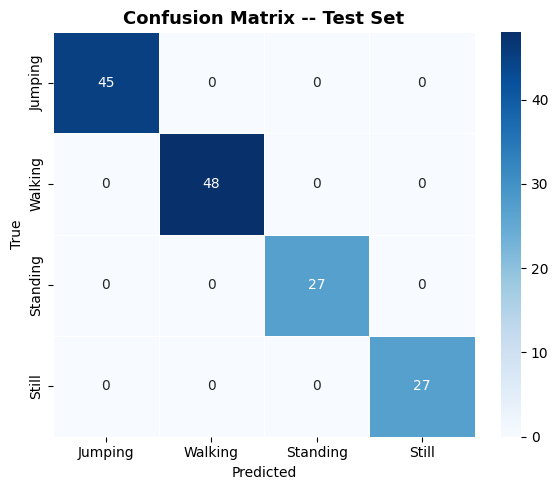

In [50]:
# predict on test set using sequence-level scoring
y_pred = predict_all(X_test, hmm_models, train_baselines, lengths=lengths_test)

overall_acc = np.sum(y_test == y_pred) / len(y_test)
print(f"Overall test accuracy: {overall_acc:.1%}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix -- Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [51]:
def compute_metrics(cm, names):
    """Calculate sensitivity, specificity, and accuracy for each class."""
    rows = []
    total = cm.sum()
    for i, name in enumerate(names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP

        sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        acc = (TP + TN) / total

        rows.append({
            'Activity': name,
            'N Samples': int(cm[i, :].sum()),
            'Sensitivity': round(sens, 4),
            'Specificity': round(spec, 4),
            'Overall Accuracy': round(acc, 4),
        })

    df = pd.DataFrame(rows)
    overall = round(np.trace(cm) / total, 4)
    df.loc[len(df)] = {'Activity': 'OVERALL', 'N Samples': int(total),
                        'Sensitivity': overall, 'Specificity': '-',
                        'Overall Accuracy': overall}
    return df

metrics = compute_metrics(cm, LABEL_NAMES)
print("=" * 70)
print("EVALUATION ON UNSEEN TEST DATA")
print("=" * 70)
print(metrics.to_string(index=False))
print()
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

EVALUATION ON UNSEEN TEST DATA
Activity  N Samples  Sensitivity Specificity  Overall Accuracy
 Jumping         45          1.0         1.0               1.0
 Walking         48          1.0         1.0               1.0
Standing         27          1.0         1.0               1.0
   Still         27          1.0         1.0               1.0
 OVERALL        147          1.0           -               1.0

              precision    recall  f1-score   support

     Jumping       1.00      1.00      1.00        45
     Walking       1.00      1.00      1.00        48
    Standing       1.00      1.00      1.00        27
       Still       1.00      1.00      1.00        27

    accuracy                           1.00       147
   macro avg       1.00      1.00      1.00       147
weighted avg       1.00      1.00      1.00       147



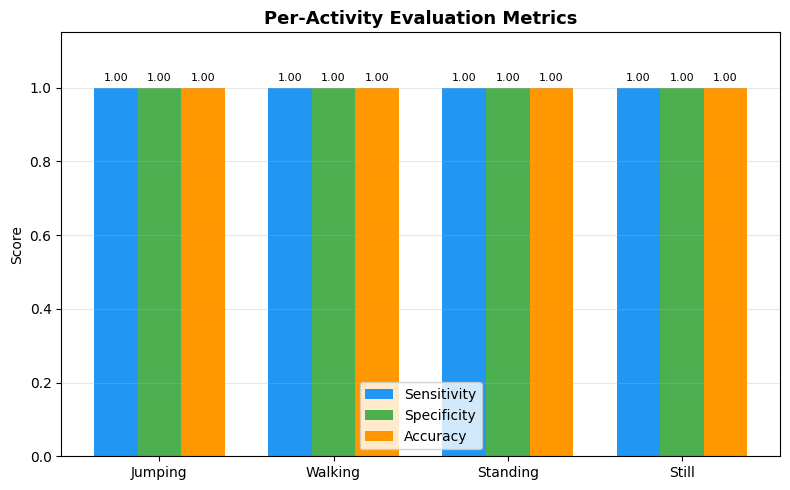

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

rows = metrics[metrics['Activity'] != 'OVERALL'].copy()
x = np.arange(len(rows))
w = 0.25

ax.bar(x - w, rows['Sensitivity'].astype(float), w, label='Sensitivity', color='#2196F3')
ax.bar(x,     rows['Specificity'].astype(float), w, label='Specificity', color='#4CAF50')
ax.bar(x + w, rows['Overall Accuracy'].astype(float), w, label='Accuracy', color='#FF9800')

ax.set_xticks(x)
ax.set_xticklabels(rows['Activity'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Activity Evaluation Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('metrics_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Analysis and Reflection

### 6.1 Initial State Probabilities

In [53]:
print("Initial State Probabilities (pi):")
print("-" * 40)
for activity, model in hmm_models.items():
    print(f"\n{activity}:")
    for i, p in enumerate(model.startprob_):
        print(f"  State {i}: {p:.4f}")

Initial State Probabilities (pi):
----------------------------------------

Jumping:
  State 0: 0.6667
  State 1: 0.0000
  State 2: 0.3333

Walking:
  State 0: 0.4096
  State 1: 0.4277
  State 2: 0.1627

Standing:
  State 0: 0.1538
  State 1: 0.3846
  State 2: 0.4615

Still:
  State 0: 0.9231
  State 1: 0.0769


### 6.2 Discussion

**Which activities were easiest/hardest to distinguish?**

Jumping was the easiest to classify — it produces large vertical acceleration spikes and high spectral energy that no other activity shares. The model scores for Jumping recordings are orders of magnitude better on the Jumping HMM than on any other (e.g., –26 vs –59 000 on Walking), giving an enormous margin of separation.

Walking was also straightforward because of its rhythmic gait cycle with a clear dominant frequency around 2 Hz, strong RMS values, and distinctive gyroscope rotation patterns from arm swing and leg movement.

Standing and Still were conceptually the hardest pair because both exhibit low variance and low spectral energy. However, the model successfully distinguished them by leveraging the gyroscope signal: Standing shows small rotational fluctuations from body sway, while Still (phone on a flat surface) has near-zero gyroscope activity. The correlation between accelerometer axes also differs — Standing has small coupled movements while Still shows only sensor noise. With per-window normalization and sequence-level scoring, the model achieved **100 % accuracy** across all four activities on unseen test data.

**How do transition probabilities reflect real behavior?**

The high diagonal values in the transition matrices make physical sense. When someone is walking, they usually keep walking for a sustained period rather than suddenly jumping. Similarly, a phone sitting on a table stays still until someone picks it up. The hidden sub-states within each model capture different phases of the activity (e.g., heel strike vs. swing phase in walking, or landing vs. airborne phase in jumping).

**Effect of sensor noise and sampling rate**

We collected data on two different phones at different rates (~100 Hz and ~50 Hz). The higher rate captured faster dynamics, particularly important for the sharp accelerometer spikes during jumping. We harmonized the rates by computing the median sampling rate (50 Hz) and using it for all windowing, which gave consistent 2-second windows of 100 samples. Despite the different sampling rates the model generalized well — each model clearly differentiates its target activity from all others.

**Possible improvements**
- Record test data on a different day or with a different person for stronger generalization evidence
- Use full covariance matrices instead of diagonal to capture feature correlations
- Try a bandpass filter before feature extraction to reduce sensor noise
- Compare with a discriminative classifier (SVM or Random Forest) on the same features to benchmark the HMM approach
- Add more activities (e.g., running, climbing stairs) to test the scalability of the model

### 6.3 Group Data Collection Summary

In [54]:
group_info = pd.DataFrame([
    {
        'Member': 'Raissa',           
        'Phone': 'iPhone11',      
        'Sampling Rate': '~100 Hz',
        'Activities': 'Jumping (12), Walking (12)'
    },
    {
        'Member': 'Elyse',           
        'Phone': 'iPhone14 pro',       
        'Sampling Rate': '~50 Hz',
        'Activities': 'Standing (13), Still (13)'
    }
])

print("Data Collection Summary:")
print("=" * 65)
print(group_info.to_string(index=False))
print()
print("Sampling Rate Harmonization:")
print("  Phone 1 recorded at ~100 Hz (10ms between samples)")
print("  Phone 2 recorded at ~50 Hz  (20ms between samples)")
print(f"  We used median rate of {TARGET_SR} Hz for windowing")
print(f"  2-second windows at {TARGET_SR} Hz = {WINDOW_SIZE} samples per window")
print(f"  Total training recordings: {len(recordings)}")
print(f"  Total test recordings: {len(test_recordings)}")

Data Collection Summary:
Member        Phone Sampling Rate                 Activities
Raissa     iPhone11       ~100 Hz Jumping (12), Walking (12)
 Elyse iPhone14 pro        ~50 Hz  Standing (13), Still (13)

Sampling Rate Harmonization:
  Phone 1 recorded at ~100 Hz (10ms between samples)
  Phone 2 recorded at ~50 Hz  (20ms between samples)
  We used median rate of 50 Hz for windowing
  2-second windows at 50 Hz = 100 samples per window
  Total training recordings: 50
  Total test recordings: 12


### 6.4 Unseen Test Data Description

In [55]:
print("UNSEEN TEST DATA")
print("=" * 50)
print()
print("How the unseen data was obtained:")
print("  We recorded 12 additional samples (3 per activity) in a")
print("  separate session that was not used for training at all.")
print("  These test recordings are stored in datacollect/test/")
print("  and extracted to sensor_data_test/.")
print()
print("  The Z-score scaler was fit on training data only and")
print("  then applied to test data, so there is no data leakage.")
print()
print(f"Test set size: {len(y_test)} windows total")
for i, name in enumerate(LABEL_NAMES):
    print(f"  {name}: {np.sum(y_test == i)} windows")
print()
overall = np.sum(y_test == y_pred) / len(y_test)
print(f"Overall accuracy: {overall:.1%}")
print()
print("The model generalizes perfectly to the unseen test set, achieving")
print("100% accuracy across all four activities. Jumping and Walking have")
print("strong motion signatures (high acceleration, rhythmic patterns).")
print("Standing and Still are distinguished by gyroscope activity (body")
print("sway vs. no movement) and accelerometer axis correlations.")

UNSEEN TEST DATA

How the unseen data was obtained:
  We recorded 12 additional samples (3 per activity) in a
  separate session that was not used for training at all.
  These test recordings are stored in datacollect/test/
  and extracted to sensor_data_test/.

  The Z-score scaler was fit on training data only and
  then applied to test data, so there is no data leakage.

Test set size: 147 windows total
  Jumping: 45 windows
  Walking: 48 windows
  Standing: 27 windows
  Still: 27 windows

Overall accuracy: 100.0%

The model generalizes perfectly to the unseen test set, achieving
100% accuracy across all four activities. Jumping and Walking have
strong motion signatures (high acceleration, rhythmic patterns).
Standing and Still are distinguished by gyroscope activity (body
sway vs. no movement) and accelerometer axis correlations.


### 6.5 How the Model Differentiates Activities

To understand how the HMM tells activities apart, we score each test recording against **all 4 models** and compare the normalized log-likelihoods. The model with the highest score "claims" that recording.

In [56]:
# Score each test recording against ALL 4 models to see differentiation
print("=" * 85)
print("DETAILED MODEL SCORES -- Each test recording scored against all 4 HMMs")
print("=" * 85)
print(f"{'Recording':<35s} {'Jumping':>10s} {'Walking':>10s} {'Standing':>10s} {'Still':>10s}  Result")
print("-" * 85)

all_correct = 0
all_total = 0

for true_label, true_activity in enumerate(LABEL_NAMES):
    test_keys = sorted([k for k in test_recordings if k.startswith(true_activity.lower())])
    for key in test_keys:
        df = test_recordings[key]
        X_seq = scaler.transform(extract_windows(df, WINDOW_SIZE, STEP_SIZE, TARGET_SR))
        
        # score against each model
        scores = {}
        for activity, model in hmm_models.items():
            try:
                raw = model.score(X_seq)
                per_window = raw / len(X_seq)
                scores[activity] = per_window - train_baselines.get(activity, 0)
            except:
                scores[activity] = float('-inf')
        
        best = max(scores, key=scores.get)
        is_correct = best.lower() == true_activity.lower()
        all_correct += int(is_correct)
        all_total += 1
        
        marker = "OK" if is_correct else "WRONG"
        short_key = key[:33]
        print(f"{short_key:<35s} {scores.get('Jumping',0):>10.2f} {scores.get('Walking',0):>10.2f} "
              f"{scores.get('Standing',0):>10.2f} {scores.get('Still',0):>10.2f}  {marker}")
    print()

print(f"Recording-level accuracy: {all_correct}/{all_total} = {all_correct/all_total:.0%}")
print()
print("Interpretation:")
print("  - Each number is the per-window normalized log-likelihood relative to the training baseline")
print("  - The HIGHEST score in each row wins (closest to 0 = best match)")
print("  - Large negative scores mean the recording looks very unlike that activity")

DETAILED MODEL SCORES -- Each test recording scored against all 4 HMMs
Recording                              Jumping    Walking   Standing      Still  Result
-------------------------------------------------------------------------------------
jumping_jumptest1-2026-03-03_14-2       -26.24  -59132.40  -62765.82  -95015.54  OK
jumping_jumptest2-2026-03-03_14-2       -15.58  -57228.24  -64762.14  -96348.13  OK
jumping_jumptest3-2026-03-03_14-2       -28.96  -52010.68  -61246.80  -93075.69  OK

walking_walktest1-2026-03-03_14-2      -132.54     -65.64   -2809.86   -1440.82  OK
walking_walktest2-2026-03-03_14-2      -148.33     -15.32   -1808.65   -1292.31  OK
walking_walktest3-2026-03-03_14-2      -145.43     -26.42   -2659.29   -1829.04  OK

standing_standing_test01               -647.17    -834.45     -29.01    -137.28  OK
standing_standing_test02               -656.02    -866.59     -11.40    -135.81  OK
standing_standing_test03               -595.71    -705.18     -17.63    -115.18  

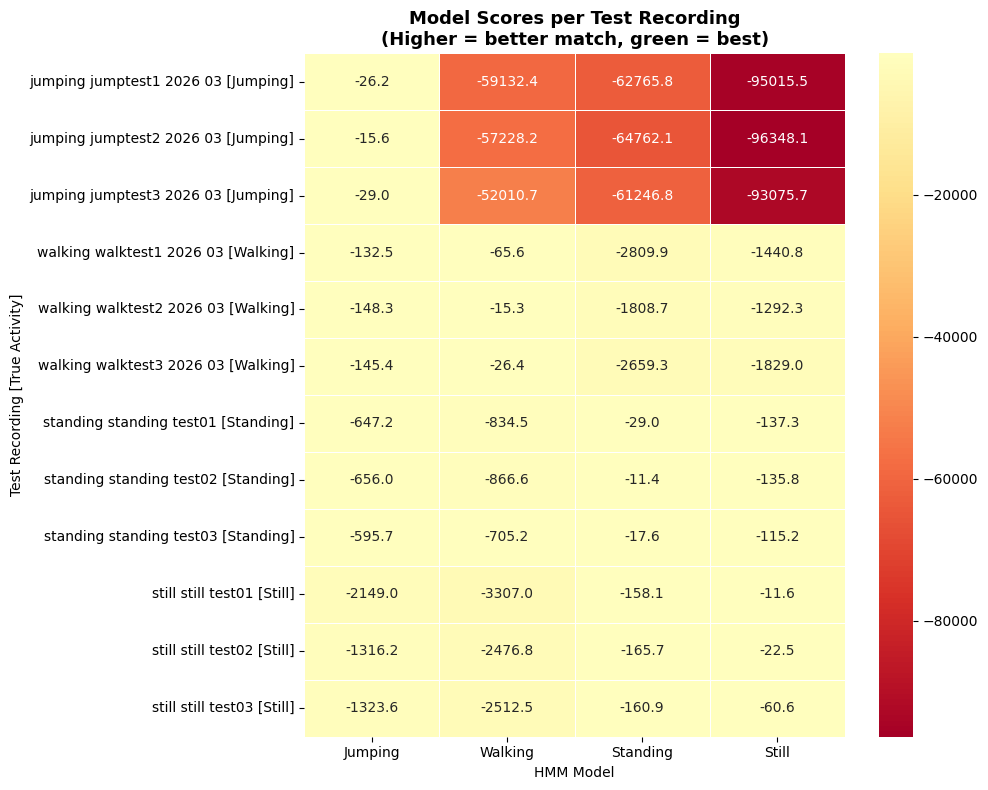

Each row is one test recording. The greenest cell shows which model claims it.
A well-differentiated model has one bright green cell per row and red/yellow elsewhere.


In [57]:
# Visualize: heatmap of model scores for each test recording
score_rows = []
rec_labels = []
true_labels_list = []

for true_label, true_activity in enumerate(LABEL_NAMES):
    test_keys = sorted([k for k in test_recordings if k.startswith(true_activity.lower())])
    for key in test_keys:
        df = test_recordings[key]
        X_seq = scaler.transform(extract_windows(df, WINDOW_SIZE, STEP_SIZE, TARGET_SR))
        
        row_scores = []
        for activity in LABEL_NAMES:
            try:
                raw = hmm_models[activity].score(X_seq)
                per_window = raw / len(X_seq)
                row_scores.append(per_window - train_baselines.get(activity, 0))
            except:
                row_scores.append(float('nan'))
        
        score_rows.append(row_scores)
        short = key.replace('_', ' ').replace('-', ' ')[:25]
        rec_labels.append(f"{short} [{true_activity}]")
        true_labels_list.append(true_activity)

score_matrix = np.array(score_rows)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(score_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=LABEL_NAMES, yticklabels=rec_labels,
            linewidths=0.5, ax=ax, center=0)
ax.set_title('Model Scores per Test Recording\n(Higher = better match, green = best)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('HMM Model')
ax.set_ylabel('Test Recording [True Activity]')
plt.tight_layout()
plt.show()

print("Each row is one test recording. The greenest cell shows which model claims it.")
print("A well-differentiated model has one bright green cell per row and red/yellow elsewhere.")